In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
#1.数据准备

#读入加州房价数据
data_path='housing.csv'
df = pd.read_csv(data_path).dropna()#.dropna()去除缺失值，非常重要！！！

#以median_house_value作为预测目标y
target='median_house_value'
y=df[target].values
#X为数据中去除了y的n部分
X=df.drop(columns=target)

#去除表头，转换为浮点数
X=pd.get_dummies(X,drop_first=True).values.astype(float)

#样本数量
n=X.shape[0]

#分割训练集和验证集(80% 20%划分)
split=int(n*0.8)

X_train, X_test=X[:split],X[split:]
Y_train,Y_test=y[:split],y[split:]

#求平均
mean=X_train.mean(axis=0)
#求标准差
std=X_train.std(axis=0)+ 1e-8
#特征标准化
X_train=(X_train-mean)/std
X_test=(X_test-mean)/std

#添加偏置项，按列拼接单位向量和X矩阵
X_train=np.c_[np.ones(X_train.shape[0]),X_train]
X_test=np.c_[np.ones(X_test.shape[0]),X_test]

In [3]:
#自己设计的线性回归类，使用岭回归（L2）
class LinearRegression:

    #构造函数，设定正则化系数alpha
    def __init__(self,alpha=1.0):
        self.alpha=alpha
        #theta是训练得到的参数
        self.theta=None

    #拟合函数
    def fit(self,X,y):
        #特征数量为X的列数
        feature_number=X.shape[1]
        #岭回归的正则方程：X的转置乘X,再加上正则化系数乘上单位阵
        A=X.T @ X+self.alpha*np.eye(feature_number)
        #截据不需要加正则化系数
        A[0,0]-=self.alpha
        #计算正规方程b的部分
        b = X.T@y
        #用numpy的linalg.solve()解方程
        self.theta=np.linalg.solve(A,b)
        return self

    #预测函数
    def predict(self,X):
        #返回X和训练得到的参数theta的叉乘
        return X@self.theta
    
    def score(self,X,y):
        #获取预测值
        y_predict=self.predict(X)
        #计算残差平方和
        ss_residual=np.sum((y-y_predict)**2)
        #计算总平方和
        ss_total=np.sum((y-np.mean(y))**2)
        #用决定系数表示score
        return 1-ss_residual/ss_total

    def mse(self,X,y):
        #计算均方误差
        return np.mean((y-self.predict(X))**2)


In [4]:
#构建模型
model=LinearRegression(alpha=1.0).fit(X_train,Y_train)

#计算
#训练集决定系数
print(f'Train R^2 = {model.score(X_train, Y_train):.4f}')   
#测试集决定系数
print(f'Test  R^2 = {model.score(X_test, Y_test):.4f}')  
#测试集 MSE    
print(f'Test  MSE = {model.mse(X_test, Y_test):.4f}')  
#均方根误差    
print(f'Test  RMSE = {np.sqrt(model.mse(X_test, Y_test)):.4f}') 

Train R^2 = 0.6279
Test  R^2 = 0.6978
Test  MSE = 4386615508.5576
Test  RMSE = 66231.5296


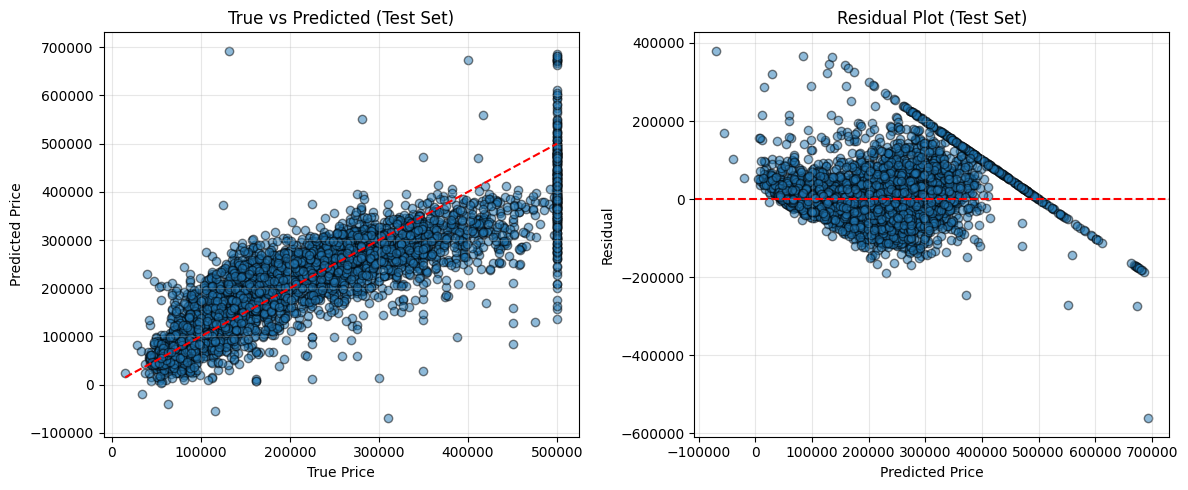

In [5]:
# 4. 画图（可视化评估效果）
# ---------------------------------------
y_pred = model.predict(X_test)           # 得到测试集的预测值
plt.figure(figsize=(12, 5))              # 设置画布大小

# 左图：真实值 vs 预测值 散点图
plt.subplot(1, 2, 1)                     # 1行2列的第1个子图
plt.scatter(Y_test, y_pred, alpha=0.5, edgecolor='k')   # 画散点，alpha控制透明度
plt.plot([Y_test.min(), Y_test.max()], 
         [Y_test.min(), Y_test.max()], 'r--')           # 画对角线（理想情况点都在线上）
plt.xlabel('True Price')
plt.ylabel('Predicted Price')
plt.title('True vs Predicted (Test Set)')
plt.grid(alpha=0.3)                      # 添加半透明网格

# 右图：残差图（真实值-预测值）
plt.subplot(1, 2, 2)                     # 1行2列的第2个子图
residuals = Y_test - y_pred.flatten()    # 计算残差并拉成一维数组
plt.scatter(y_pred.flatten(), residuals, alpha=0.5, edgecolor='k')
plt.axhline(y=0, color='r', linestyle='--')  # 画 y=0 的水平参考线
plt.xlabel('Predicted Price')
plt.ylabel('Residual')
plt.title('Residual Plot (Test Set)')
plt.grid(alpha=0.3)

plt.tight_layout()                       # 自动调整子图间距防止重叠
plt.show()                               # 显示图形